In [11]:
# Import

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set()
print("Working dir:", os.getcwd())

Working dir: C:\Users\gurur\Desktop\ML_Project\customer_segmentation


In [12]:
#Loading Data

data_path = "data/customers.csv"   # place your CSV here if you have one

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Loaded dataset from", data_path)
else:
    # Create a sample "Mall Customers" style dataset
    rng = np.random.RandomState(42)
    n = 300
    age = rng.randint(18, 70, size=n)
    annual_income = rng.normal(loc=60, scale=30, size=n).clip(10, 150)  
    spending_score = rng.randint(1, 101, size=n)                       
    # Add a simple frequency & recency proxy
    frequency = rng.poisson(3, size=n).clip(1, 20)
    recency = rng.randint(1, 365, size=n)  # days since last purchase

    df = pd.DataFrame({
        "Age": age,
        "AnnualIncome_k": np.round(annual_income, 1),
        "SpendingScore": spending_score,
        "Frequency": frequency,
        "Recency": recency
    })
    os.makedirs("data", exist_ok=True)
    df.to_csv("data/sample_customers.csv", index=False)
    print("No customers.csv found — generated sample data and saved to data/sample_customers.csv")

df.head()

No customers.csv found — generated sample data and saved to data/sample_customers.csv


,Age,AnnualIncome_k,SpendingScore,Frequency,Recency
0,56,55.6,43,4,106
1,69,65.4,75,6,217
2,46,88.9,23,2,205
3,32,28.1,55,3,70
4,60,63.3,80,3,44


Rows, cols: (300, 5)


,Age,AnnualIncome_k,SpendingScore,Frequency,Recency
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,43.320000,59.568667,48.120000,3.163333,177.153333
std,15.326686,30.194835,29.400799,1.760773,100.624188
min,18.000000,10.000000,1.000000,1.000000,1.000000
25%,30.000000,37.675000,23.000000,2.000000,90.500000
50%,43.500000,59.800000,47.500000,3.000000,167.500000
75%,56.000000,82.950000,72.250000,4.000000,265.500000
max,69.000000,150.000000,100.000000,10.000000,364.000000


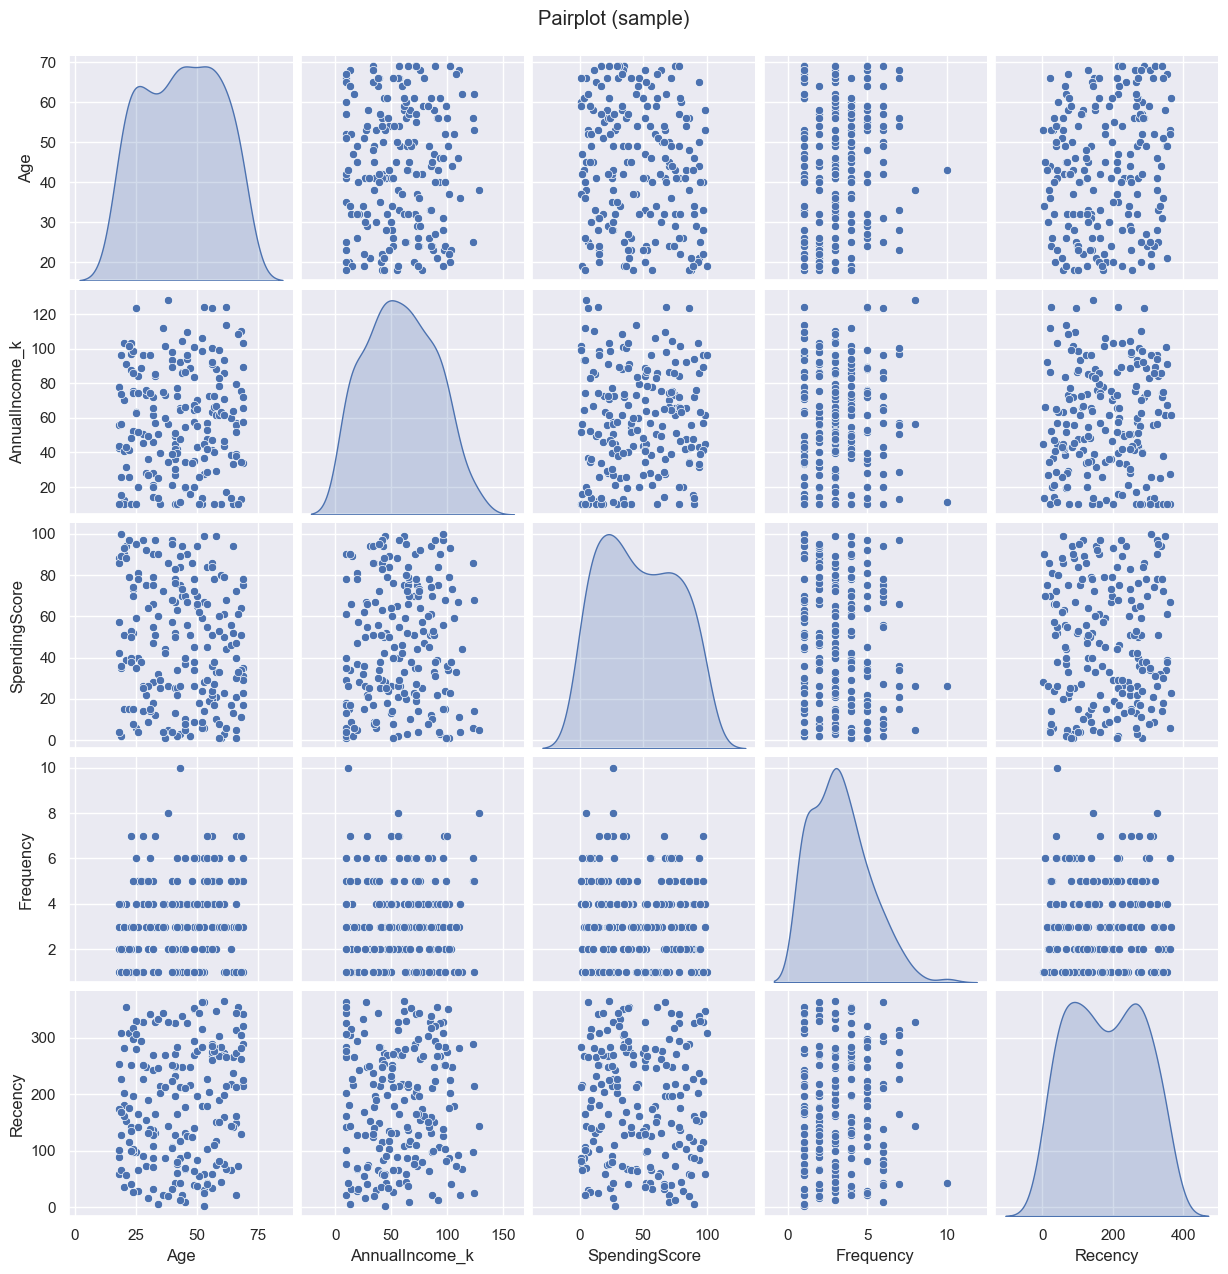

In [13]:
# Quick EDA

print("Rows, cols:", df.shape)
display(df.describe())

# pairplot for quick view (may take a bit)
sns.pairplot(df.sample(min(200, len(df))), diag_kind="kde")
plt.suptitle("Pairplot (sample)", y=1.02)
plt.show()

In [14]:
#Choose Featchers and scales

features = ["AnnualIncome_k", "SpendingScore", "Frequency", "Recency", "Age"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix shape:", X_scaled.shape)


Feature matrix shape: (300, 5)


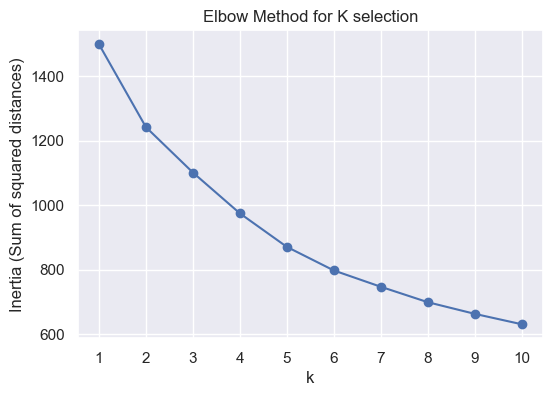

In [15]:
#elbow method to choose k

inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, '-o')
plt.xlabel("k")
plt.ylabel("Inertia (Sum of squared distances)")
plt.xticks(K_range)
plt.title("Elbow Method for K selection")
plt.grid(True)
plt.show()

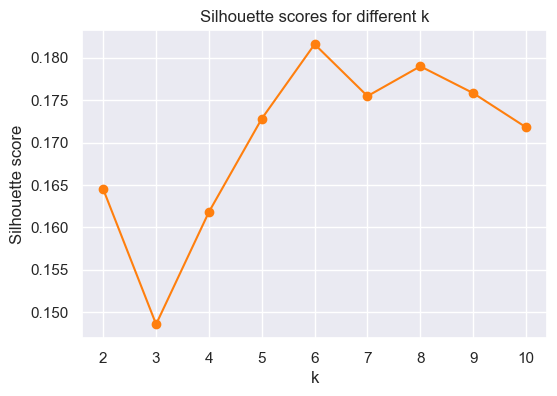

In [16]:
#silhouette scores (helps choose k)

sil_scores = []
K_range2 = range(2, 11)
for k in K_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(list(K_range2), sil_scores, '-o', color='tab:orange')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores for different k")
plt.grid(True)
plt.show()

In [17]:
#fit final KMeans and attach cluster labels

# Replace k with chosen value from elbow + silhouette. We'll suggest k=4 as typical.
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

# Save the cluster centers (in original scaled space -> invert transform to original)
centers_scaled = km.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=features)
print("Cluster centers (original scale):")
display(centers_df)

df['cluster'] = df['cluster'].astype(int)
df.cluster.value_counts().sort_index()

Cluster centers (original scale):


,AnnualIncome_k,SpendingScore,Frequency,Recency,Age
0,73.600000,24.637681,4.884058,156.840580,49.521739
1,85.343750,71.796875,2.968750,240.062500,36.656250
2,49.278723,57.212766,2.319149,89.159574,36.021277
3,36.958904,37.849315,2.794521,254.506849,52.698630


cluster
0    69
1    64
2    94
3    73
Name: count, dtype: int64

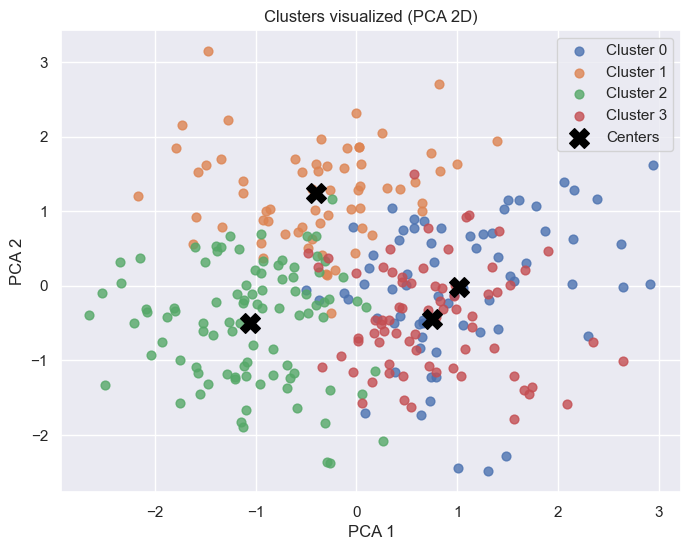

In [18]:
#2D visualization with PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
palette = sns.color_palette("tab10", k)
for cluster in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster
    plt.scatter(X_pca[mask,0], X_pca[mask,1], s=40, label=f"Cluster {cluster}", alpha=0.8)

# plot centers (project centers to PCA space)
centers_pca = pca.transform(centers_scaled)
plt.scatter(centers_pca[:,0], centers_pca[:,1], s=200, marker='X', c='black', label='Centers')
plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
plt.title("Clusters visualized (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()

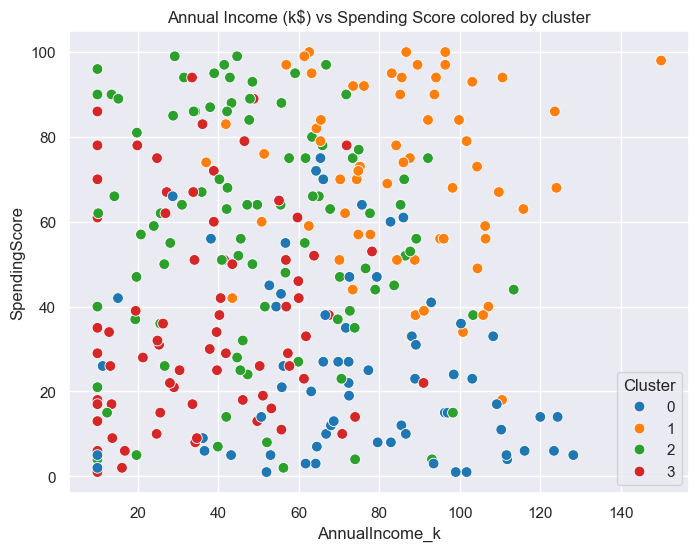

In [19]:
#2D scatter plot

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='AnnualIncome_k', y='SpendingScore', hue='cluster', palette=palette, s=60)
plt.title("Annual Income (k$) vs Spending Score colored by cluster")
plt.legend(title='Cluster')
plt.show()

In [20]:
#save results

os.makedirs("output", exist_ok=True)
df.to_csv("output/clustered_customers.csv", index=False)
centers_df.to_csv("output/cluster_centers.csv", index=False)
plt.savefig("output/last_figure.png")  # saves current figure; you can also save specific plots
print("Saved clustered_customers.csv and cluster_centers.csv in output/")

Saved clustered_customers.csv and cluster_centers.csv in output/


<Figure size 640x480 with 0 Axes>